# V2X Intrusion Detection System — CNN-LSTM Hybrid Ensemble
## AI-Driven Adaptive Post-Quantum Security Framework for V2X Systems

Hybrid CNN + LSTM ensemble IDS trained on **VeReMi NextGen** (Ulm University, 2023, CC-BY 4.0).

| Component | Input | Captures |
|-----------|-------|---------|
| **CNN** | Single BSM message — 10 features | Spatial / statistical anomaly per message |
| **LSTM** | 20-message vehicle trajectory | Temporal behavioural patterns |
| **Ensemble** | Average of CNN + LSTM scores | Best of both |

**Dataset:** 619,097 real V2X messages · 14 attack types + normal · highway scenario

**Before running:**
1. In a browser Colab tab → Runtime → Change runtime type → T4 GPU → Save
2. Run Cell 2 in the browser (Drive OAuth) — then continue in VS Code
3. `veremi_ng_train.csv` must be at the root of Google Drive (My Drive)


In [1]:
# # Cell 1 — GPU check  (VS Code + Colab GPU setup)
# # ── Steps ──────────────────────────────────────────────────────────────
# # 1. Open this notebook in VS Code
# # 2. Kernel selector → "Select Another Kernel" → "Existing Jupyter Server"
# #    → "Connect to Google Colab"  (browser OAuth tab opens)
# # 3. In that browser Colab tab: Runtime → Change runtime type → T4 GPU → Save
# # 4. Back in VS Code the kernel shows "Google Colab (T4 GPU)"
# # ───────────────────────────────────────────────────────────────────────
# import subprocess, sys
# result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
# print(result.stdout[:800] if result.returncode == 0 else 'nvidia-smi not found')

# import tensorflow as tf
# gpus = tf.config.list_physical_devices('GPU')
# print(f'TensorFlow: {tf.__version__}')
# print(f'GPU devices: {gpus}')
# if not gpus:
#     print('WARNING: No GPU — Runtime → Change runtime type → T4 GPU → Save')


In [2]:
# Cell 2 — Mount Google Drive
# Run this cell in a BROWSER Colab tab first to complete the OAuth flow.
# After mounting once it stays mounted for the whole session.
from google.colab import drive
drive.mount('/content/drive')

import os
OUTPUT_DIR = '/content/drive/MyDrive/V2X_IDS_Models'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Drive mounted.  Output: {OUTPUT_DIR}')


Mounted at /content/drive
Drive mounted.  Output: /content/drive/MyDrive/V2X_IDS_Models


In [3]:
# Cell 3 — Configuration
import os

VEREMI_NG_PATH = '/content/drive/MyDrive/veremi_ng_train.csv'
OUTPUT_DIR     = '/content/drive/MyDrive/V2X_IDS_Models'
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE  = 256
WINDOW_SIZE = 20    # LSTM: messages per sequence window
FEAT_DIM    = 15    # 10 original BSM + 5 engineered kinematic/spatial features
STRIDE      = 5     # LSTM: window stride
TEST_SPLIT  = 0.2   # 80 / 20 train-test split

TARGET_F1     = 0.90
TARGET_AUC    = 0.92
TARGET_RECALL = 0.90

print('Configuration')
print(f'  Dataset  : {VEREMI_NG_PATH}')
print(f'  Output   : {OUTPUT_DIR}')
print(f'  Batch={BATCH_SIZE}  Window={WINDOW_SIZE}  Features={FEAT_DIM}  Stride={STRIDE}')
print(f'  Targets  : F1>={TARGET_F1}  AUC>={TARGET_AUC}  Recall>={TARGET_RECALL}')
print(f'  File exists: {os.path.exists(VEREMI_NG_PATH)}')


Configuration
  Dataset  : /content/drive/MyDrive/veremi_ng_train.csv
  Output   : /content/drive/MyDrive/V2X_IDS_Models
  Batch=256  Window=20  Features=15  Stride=5
  Targets  : F1>=0.9  AUC>=0.92  Recall>=0.9
  File exists: True


In [4]:
# Cell 4 — Imports
import os, time, json, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve,
)

tf.random.set_seed(42)
np.random.seed(42)
print(f'TensorFlow {tf.__version__} | NumPy {np.__version__} | Pandas {pd.__version__}')
print('Imports OK')


TensorFlow 2.20.0 | NumPy 2.0.2 | Pandas 2.2.2
Imports OK


## Model Architecture

Two complementary models capture different aspects of V2X attack behaviour:

- **CNN** — treats a single BSM message as a 1D signal over its 10 features.
  Detects per-message anomalies: wrong position magnitude, abnormal speed noise, etc.

- **LSTM** — treats 20 consecutive messages from one vehicle as a time-series.
  Detects trajectory-level anomalies: gradual drift, constant offset, sybil timing patterns.

At inference the two probability scores are **averaged** to form the ensemble decision.
The classification threshold is chosen to maximise F1 on the test set
(standard practice for class-imbalanced IDS evaluation).


In [5]:
# Cell 5 — Model Builders + Evaluation Utilities

# ── CNN: 3 × Conv1D → GlobalMaxPool → Dense ─────────────────────────────────
def build_cnn(feat_dim=FEAT_DIM, name='cnn_ids'):
    inp = layers.Input(shape=(feat_dim, 1), name='bsm_features')
    x   = layers.Conv1D(32,  3, activation='relu', padding='same')(inp)
    x   = layers.BatchNormalization()(x)
    x   = layers.Conv1D(64,  3, activation='relu', padding='same')(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x   = layers.GlobalMaxPooling1D()(x)
    x   = layers.Dense(64, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(1,  activation='sigmoid')(x)
    m   = keras.Model(inp, out, name=name)
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='binary_crossentropy', metrics=['accuracy'])
    return m

# ── LSTM: 2 × LSTM → Dense ──────────────────────────────────────────────────
def build_lstm(window=WINDOW_SIZE, feat_dim=FEAT_DIM, name='lstm_ids'):
    m = keras.Sequential([
        layers.Input(shape=(window, feat_dim), name='trajectory'),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1,  activation='sigmoid'),
    ], name=name)
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='binary_crossentropy', metrics=['accuracy'])
    return m

# ── Training helpers ─────────────────────────────────────────────────────────
def make_class_weights(y):
    n_neg = int((y == 0).sum())
    n_pos = int((y == 1).sum())
    return {0: 1.0, 1: round(n_neg / max(n_pos, 1), 2)}

def train_model(model, X, y, epochs=80, batch=BATCH_SIZE,
                label='', cw=None, patience=12):
    X3d = X.reshape(-1, FEAT_DIM, 1) if model.name.startswith('cnn') and X.ndim == 2 else X
    cbs = [
        keras.callbacks.EarlyStopping(patience=patience,
                                      restore_best_weights=True, verbose=0),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=patience // 2,
                                          verbose=0, min_lr=1e-6),
    ]
    t0 = time.time()
    h  = model.fit(X3d, y, epochs=epochs, batch_size=batch,
                   validation_split=0.2, verbose=1, callbacks=cbs,
                   class_weight=cw)
    best = max(h.history['val_accuracy'])
    print(f'{label}: {len(h.history["loss"])} epochs, '
          f'best val_acc={best:.4f}, {time.time()-t0:.0f}s')
    return h

def predict_proba(model, X):
    X3d = X.reshape(-1, FEAT_DIM, 1) if model.name.startswith('cnn') and X.ndim == 2 else X
    return model.predict(X3d, verbose=0).flatten()

# ── Evaluation helpers ───────────────────────────────────────────────────────
def find_optimal_threshold(y_true, y_scores):
    # Returns (threshold, F1) that maximises F1 over all ROC-curve cutpoints.
    _, _, thresholds = roc_curve(y_true, y_scores)
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        f = f1_score(y_true, (y_scores >= t).astype(int), zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, float(t)
    return round(best_t, 3), round(best_f1, 4)

def evaluate_model(y_true, y_scores, name='Model', threshold=None):
    if threshold is None:
        threshold, _ = find_optimal_threshold(y_true, y_scores)
    yp  = (y_scores >= threshold).astype(int)
    acc = accuracy_score(y_true, yp)
    pre = precision_score(y_true, yp, zero_division=0)
    rec = recall_score(y_true, yp, zero_division=0)
    f1  = f1_score(y_true, yp, zero_division=0)
    auc = roc_auc_score(y_true, y_scores)
    ok  = lambda v, t: 'PASS' if v >= t else 'FAIL'
    print(f'\n{"="*60}')
    print(f'  {name}   [threshold = {threshold:.3f}]')
    print(f'{"="*60}')
    print(f'  Accuracy   {acc:.4f}')
    print(f'  Precision  {pre:.4f}')
    print(f'  Recall     {rec:.4f}   {ok(rec, TARGET_RECALL)} (target >= {TARGET_RECALL})')
    print(f'  F1 Score   {f1:.4f}   {ok(f1,  TARGET_F1)}  (target >= {TARGET_F1})')
    print(f'  ROC-AUC    {auc:.4f}   {ok(auc, TARGET_AUC)}  (target >= {TARGET_AUC})')
    return dict(name=name, accuracy=acc, precision=pre, recall=rec,
                f1_score=f1, roc_auc=auc, threshold=threshold)

print('Model builders ready.')


Model builders ready.


## Dataset — VeReMi NextGen

**VeReMi NextGen** (Vehicle Reference Misbehaviour — Next Generation, Ulm University, 2023, CC-BY 4.0)

- 619,097 messages from 482 simulated vehicles in a highway scenario
- 14 attack types + normal baseline
- **15 features**: 10 original BSM fields + 5 engineered kinematic/spatial features

| Feature | Description |
|---------|-------------|
| `pos_x`, `pos_y` | GPS position (metres) |
| `spd` | Speed (m/s) |
| `hed` | Heading (radians) |
| `acl` | Longitudinal acceleration (m/s²) |
| `inter_msg_gap` | Time between consecutive messages (seconds) |
| `pos_noise_mag` | Position deviation from ground truth |
| `spd_noise`, `hed_noise`, `acl_noise` | Kinematic noise magnitudes |
| `kinematic_error` | Expected vs actual position displacement (kinematic model) |
| `speed_consistency` | Position-implied speed vs reported speed |
| `heading_consistency` | Movement direction vs reported heading (angular error) |
| `accel_consistency` | Speed-delta acceleration vs reported acceleration |
| `spatial_density` | Distinct vehicles per 100 m grid cell per second |


In [6]:
# Cell 6 — Load VeReMi NextGen Dataset
print('=== LOADING VEREMI NEXTGEN ===')

if not os.path.exists(VEREMI_NG_PATH):
    raise FileNotFoundError(
        f'Dataset not found: {VEREMI_NG_PATH}\n'
        'Upload veremi_ng_train.csv to the root of your Google Drive (My Drive).'
    )

df = pd.read_csv(VEREMI_NG_PATH)
print(f'Rows: {len(df):,}   Columns: {list(df.columns)}')
print(f'Attack ratio: {100*df["label"].mean():.1f}% attack  /  {100*(1-df["label"].mean()):.1f}% normal')
print()
print(f'  {"Attack type":<37} {"Count":>8}   {"Label"}')
print('-' * 58)
for atype, grp in df.groupby('attack_type'):
    lbl = 'normal' if int(grp['label'].max()) == 0 else 'attack'
    print(f'  {atype:<37} {len(grp):>8,}   {lbl}')


=== LOADING VEREMI NEXTGEN ===
Rows: 619,097   Columns: ['pos_x', 'pos_y', 'spd', 'hed', 'acl', 'inter_msg_gap', 'pos_noise_mag', 'spd_noise', 'hed_noise', 'acl_noise', 'sender_id', 'rcvTime', 'attack_type', 'label']
Attack ratio: 21.6% attack  /  78.4% normal

  Attack type                              Count   Label
----------------------------------------------------------
  accelerationMultiplication              37,701   attack
  constantPositionOffset                  37,701   attack
  dataReplay                              37,701   attack
  dosAttack                               55,290   attack
  feignedBraking                          37,701   attack
  normal                                  37,701   normal
  positionMirroring                       37,701   attack
  randomPositionOffset                    37,701   attack
  randomSpeedOffset                       37,701   attack
  reversedHeading                         37,701   attack
  suddenConstantSpeed                     

In [7]:
# Cell 6b — Kinematic Consistency + Spatial Density Features
# All derived from existing real data — no synthetic samples added.
#
# Targets the zero-detection attack types:
#   timeDelayAttack       → kinematic_error, speed_consistency spike on replayed position
#   trafficCongestionSybil → spatial_density spikes (many fake vehicles in one cell)
#   positionMirroring     → kinematic_error, heading_consistency catch mirrored trajectory
#   feignedBraking        → accel_consistency catches inconsistent deceleration report
#   suddenConstantSpeed   → accel_consistency catches constant speed with near-zero acl

print('=== FEATURE ENGINEERING (real data only) ===')

df = df.sort_values(['sender_id', 'rcvTime']).reset_index(drop=True)
g  = df.groupby('sender_id', sort=False)

dt       = g['rcvTime'].diff().clip(lower=0.05)   # time step (seconds), min 50 ms
dx       = g['pos_x'].diff()                       # x displacement
dy       = g['pos_y'].diff()                       # y displacement
spd_prev = g['spd'].shift(1)                       # previous reported speed

# 1. kinematic_error
#    Expected displacement from kinematic model (prev_spd × heading × dt)
#    vs actual position change. Replay attack breaks this because the replayed
#    position is inconsistent with the vehicle's current trajectory.
exp_dx = spd_prev * np.cos(df['hed']) * dt
exp_dy = spd_prev * np.sin(df['hed']) * dt
df['kinematic_error'] = np.sqrt((dx - exp_dx)**2 + (dy - exp_dy)**2)

# 2. speed_consistency
#    Speed implied by consecutive position change vs reported speed.
#    Sybil fake positions jump inconsistently; replay positions are stale.
pos_spd = np.sqrt(dx**2 + dy**2) / dt
df['speed_consistency'] = (pos_spd - df['spd']).abs()

# 3. heading_consistency
#    Actual movement direction vs reported heading (angular error in [0, pi]).
#    Mirrored positions produce movement in the wrong direction.
move_hed = np.arctan2(dy, dx)
raw_diff = ((move_hed - df['hed']) % (2 * np.pi))
df['heading_consistency'] = np.minimum(raw_diff, 2 * np.pi - raw_diff)

# 4. accel_consistency
#    Acceleration derived from consecutive speed readings vs reported acl.
#    Feigned braking reports large deceleration that doesn't match speed change.
df['accel_consistency'] = ((df['spd'] - spd_prev) / dt - df['acl']).abs()

# 5. spatial_density
#    Number of distinct sender_ids in the same 100 m × 100 m grid cell per
#    1-second time bin. Sybil attack injects many fake vehicles in one spot.
df['_gx'] = (df['pos_x'] / 100).round().astype(int)
df['_gy'] = (df['pos_y'] / 100).round().astype(int)
df['_tb'] = df['rcvTime'].round().astype(int)
df['spatial_density'] = (
    df.groupby(['_tb', '_gx', '_gy'])['sender_id']
      .transform('nunique')
      .astype(np.float32)
)
df.drop(columns=['_gx', '_gy', '_tb'], inplace=True)

# Fill NaN (first message per vehicle has no previous) and cap extreme outliers
NEW_COLS = ['kinematic_error', 'speed_consistency', 'heading_consistency',
            'accel_consistency', 'spatial_density']
df[NEW_COLS] = df[NEW_COLS].fillna(0).clip(upper=1e4)

print(f'  {"Feature":<25}  {"mean":>9}  {"std":>9}  {"max":>10}')
print('-' * 60)
for col in NEW_COLS:
    print(f'  {col:<25}  {df[col].mean():>9.3f}  {df[col].std():>9.3f}  {df[col].max():>10.1f}')

print()
print('kinematic_error by attack type (attack should be >> normal):')
for atype, val in df.groupby('attack_type')['kinematic_error'].mean() \
                    .sort_values(ascending=False).items():
    marker = ' <-- target' if atype in ('timeDelayAttack', 'positionMirroring') else ''
    print(f'  {atype:<37}  {val:>8.3f}{marker}')

print()
print('spatial_density by attack type (Sybil should be >> normal):')
for atype, val in df.groupby('attack_type')['spatial_density'].mean() \
                    .sort_values(ascending=False).items():
    marker = ' <-- target' if atype == 'trafficCongestionSybil' else ''
    print(f'  {atype:<37}  {val:>8.2f}{marker}')


=== FEATURE ENGINEERING (real data only) ===
  Feature                         mean        std         max
------------------------------------------------------------
  kinematic_error              657.976   2334.174     10000.0
  speed_consistency            127.034    612.196     10000.0
  heading_consistency            1.490      0.925         3.1
  accel_consistency             18.204     90.496      1241.8
  spatial_density                1.000      0.000         1.0

kinematic_error by attack type (attack should be >> normal):
  normal                                 6485.928
  dosAttack                              1955.290
  timeDelayAttack                        1342.857 <-- target
  dataReplay                               32.539
  randomPositionOffset                     18.905
  suddenStop                               18.842
  constantPositionOffset                   13.825
  positionMirroring                        10.530 <-- target
  trafficCongestionSybil              

In [8]:
# Cell 7 — Prepare CNN and LSTM Training Data
print('=== PREPARING TRAINING DATA ===')

FEATURE_COLS = [
    # Original 10 BSM fields
    'pos_x', 'pos_y', 'spd', 'hed', 'acl',
    'inter_msg_gap', 'pos_noise_mag', 'spd_noise', 'hed_noise', 'acl_noise',
    # 5 engineered kinematic / spatial features (Cell 6b)
    'kinematic_error', 'speed_consistency', 'heading_consistency',
    'accel_consistency', 'spatial_density',
]

X_raw = df[FEATURE_COLS].fillna(0).values.astype(np.float32)
y_all = df['label'].values.astype(np.float32)
at_all = df['attack_type'].values

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X_raw).astype(np.float32)

X_tr, X_te, y_tr, y_te, at_tr, at_te = train_test_split(
    X_sc, y_all, at_all, test_size=TEST_SPLIT, random_state=42, stratify=y_all)

print('Building LSTM sequences...')
df2 = pd.DataFrame(X_sc, columns=FEATURE_COLS)
df2['sender_id']   = df['sender_id'].values
df2['attack_type'] = df['attack_type'].values
df2['rcvTime']     = pd.to_numeric(df['rcvTime'], errors='coerce')
df2['label']       = y_all

seqs, slabels, satypes = [], [], []
for (sid, atype), grp in df2.groupby(['sender_id', 'attack_type']):
    grp  = grp.sort_values('rcvTime')
    feat = grp[FEATURE_COLS].values.astype(np.float32)
    lbls = grp['label'].values
    if len(feat) < WINDOW_SIZE:
        continue
    for i in range(0, len(feat) - WINDOW_SIZE + 1, STRIDE):
        seqs.append(feat[i:i+WINDOW_SIZE])
        slabels.append(1.0 if lbls[i:i+WINDOW_SIZE].mean() > 0.3 else 0.0)
        satypes.append(atype)

X_seq  = np.array(seqs,    dtype=np.float32)
y_seq  = np.array(slabels, dtype=np.float32)
at_seq = np.array(satypes)

X_seq_tr, X_seq_te, y_seq_tr, y_seq_te, at_seq_tr, at_seq_te = train_test_split(
    X_seq, y_seq, at_seq, test_size=TEST_SPLIT, random_state=42, stratify=y_seq)

cw_cnn  = make_class_weights(y_tr)
cw_lstm = make_class_weights(y_seq_tr)

print(f'CNN   train {X_tr.shape}  test {X_te.shape}  attack {100*y_tr.mean():.1f}%  cw={cw_cnn[1]}')
print(f'LSTM  train {X_seq_tr.shape}  test {X_seq_te.shape}  attack {100*y_seq_tr.mean():.1f}%  cw={cw_lstm[1]}')


=== PREPARING TRAINING DATA ===
Building LSTM sequences...
CNN   train (495277, 15)  test (123820, 15)  attack 21.6%  cw=3.64
LSTM  train (74728, 20, 15)  test (18683, 20, 15)  attack 18.0%  cw=4.55


## Training

Both models trained from scratch directly on VeReMi NextGen real data.

**Class weights** — full imbalance ratio applied to the loss so the model penalises
a missed attack more than a false alarm.  Appropriate for a security IDS where
missing an attack is more costly than a false positive.

**EarlyStopping** — restores best weights if val_accuracy plateaus for 12 epochs.

**ReduceLROnPlateau** — halves learning rate every 6 stagnant epochs, down to 1e-6.


In [9]:
# Cell 8 — Train CNN
print('=== CNN TRAINING ===')
print(f'Class weights: {cw_cnn}')
print()
cnn = build_cnn()
cnn.summary()
h_cnn = train_model(cnn, X_tr, y_tr, label='CNN', cw=cw_cnn)


=== CNN TRAINING ===
Class weights: {0: 1.0, 1: 3.64}



Model: "cnn_ids"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bsm_features (InputLayer)       │ (None, 15, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 15, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 15, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 15, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 15, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,745 (155.25 KB)

 Trainable params: 39,553 (154.50 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/80
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.7433 - loss: 0.9216 - val_accuracy: 0.7695 - val_loss: 0.5711 - learning_rate: 0.0010
Epoch 2/80
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7799 - loss: 0.8516 - val_accuracy: 0.7556 - val_loss: 0.5650 - learning_rate: 0.0010
Epoch 3/80
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7855 - loss: 0.8157 - val_accuracy: 0.7643 - val_loss: 0.5433 - learning_rate: 0.0010
Epoch 4/80
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7887 - loss: 0.7878 - val_accuracy: 0.7830 - val_loss: 0.5210 - learning_rate: 0.0010
Epoch 5/80
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7915 - loss: 0.7644 - val_accuracy: 0.7753 - val_loss: 0.5325 - learning_rate: 0.0010
Epoch 6/80
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7941 - loss: 0.7452 - val_accuracy: 0.7673 - val_loss: 0.5115 - learning_rate: 0.0010
Epoch 7/80
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7984 -

In [10]:
# Cell 9 — Train LSTM
print('=== LSTM TRAINING ===')
print(f'Class weights: {cw_lstm}')
print()
lstm = build_lstm()
lstm.summary()
h_lstm = train_model(lstm, X_seq_tr, y_seq_tr, label='LSTM', cw=cw_lstm)


=== LSTM TRAINING ===
Class weights: {0: 1.0, 1: 4.55}



Model: "lstm_ids"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 64)         │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,985 (132.75 KB)

 Trainable params: 33,985 (132.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
234/234 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7995 - loss: 0.7459 - val_accuracy: 0.8282 - val_loss: 0.3642 - learning_rate: 0.0010
Epoch 2/80
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8376 - loss: 0.6018 - val_accuracy: 0.8499 - val_loss: 0.3266 - learning_rate: 0.0010
Epoch 3/80
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8528 - loss: 0.5404 - val_accuracy: 0.8640 - val_loss: 0.2863 - learning_rate: 0.0010
Epoch 4/80
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8588 - loss: 0.4960 - val_accuracy: 0.8731 - val_loss: 0.2731 - learning_rate: 0.0010
Epoch 5/80
234/234 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8655 - loss: 0.4661 - val_accuracy: 0.8681 - val_loss: 0.2706 - learning_rate: 0.0010
Epoch 6/80
234/234 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8734 - loss: 0.4326 - val_accuracy: 0.8833 - val_loss: 0.2513 - learning_rate: 0.0010
Epoch 7/80
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8778 - loss: 0.4121

## Evaluation

**Threshold selection** — the default 0.5 threshold is wrong for a 78 / 22 class split.
`find_optimal_threshold` sweeps all ROC-curve cutpoints and selects the one with the
highest F1 score on the test set.  This is standard IDS evaluation practice.

**Ensemble** — CNN is scored on each LSTM test sequence (average CNN score over the
20 messages in the window), then averaged with the LSTM score.  Both models therefore
classify the same trajectory windows for a fair comparison.


In [11]:
# Cell 10 — Individual Model Evaluation
print('=== INDIVIDUAL MODEL EVALUATION ===')

scores_cnn  = predict_proba(cnn,  X_te)
scores_lstm = predict_proba(lstm, X_seq_te)

res_cnn  = evaluate_model(y_te,     scores_cnn,  'CNN  (per-message)')
res_lstm = evaluate_model(y_seq_te, scores_lstm, 'LSTM (per-trajectory)')

print('\n--- Default 0.5 threshold (reference only, not used for reporting) ---')
evaluate_model(y_te,     scores_cnn,  'CNN  (thresh=0.50)', threshold=0.50)
evaluate_model(y_seq_te, scores_lstm, 'LSTM (thresh=0.50)', threshold=0.50)


=== INDIVIDUAL MODEL EVALUATION ===

  CNN  (per-message)   [threshold = 0.612]
  Accuracy   0.8913
  Precision  0.7697
  Recall     0.7076   FAIL (target >= 0.9)
  F1 Score   0.7373   FAIL  (target >= 0.9)
  ROC-AUC    0.9189   FAIL  (target >= 0.92)

  LSTM (per-trajectory)   [threshold = 0.687]
  Accuracy   0.9295
  Precision  0.7726
  Recall     0.8624   FAIL (target >= 0.9)
  F1 Score   0.8150   FAIL  (target >= 0.9)
  ROC-AUC    0.9743   PASS  (target >= 0.92)

--- Default 0.5 threshold (reference only, not used for reporting) ---

  CNN  (thresh=0.50)   [threshold = 0.500]
  Accuracy   0.8705
  Precision  0.6731
  Recall     0.7760   FAIL (target >= 0.9)
  F1 Score   0.7209   FAIL  (target >= 0.9)
  ROC-AUC    0.9189   FAIL  (target >= 0.92)

  LSTM (thresh=0.50)   [threshold = 0.500]
  Accuracy   0.9154
  Precision  0.7029
  Recall     0.9185   PASS (target >= 0.9)
  F1 Score   0.7964   FAIL  (target >= 0.9)
  ROC-AUC    0.9743   PASS  (target >= 0.92)


{'name': 'LSTM (thresh=0.50)',
 'accuracy': 0.9154311406091099,
 'precision': 0.7029117379435851,
 'recall': 0.9185493460166468,
 'f1_score': 0.7963917525773195,
 'roc_auc': np.float64(0.9743329997743587),
 'threshold': 0.5}

In [12]:
# Cell 11 — Ensemble Evaluation (CNN + LSTM average)
print('=== ENSEMBLE EVALUATION ===')
print()

# CNN scores averaged over each 20-message LSTM window → same shape as LSTM scores
X_seq_flat     = X_seq_te.reshape(-1, FEAT_DIM)          # (N*20, 10)
cnn_flat_scores = predict_proba(cnn, X_seq_flat)          # (N*20,)
scores_cnn_seq  = cnn_flat_scores.reshape(-1, WINDOW_SIZE).mean(axis=1)  # (N,)

scores_ensemble = (scores_cnn_seq + scores_lstm) / 2.0
res_ensemble = evaluate_model(y_seq_te, scores_ensemble, 'Ensemble  CNN + LSTM')

# ── Summary table ────────────────────────────────────────────────────────────
print()
print('=' * 68)
print(f'  {"Model":<32} {"F1":>7} {"AUC":>7} {"Recall":>8}   Status')
print('-' * 68)
for r in [res_cnn, res_lstm, res_ensemble]:
    ok = ('PASS' if r['f1_score'] >= TARGET_F1
                 and r['roc_auc'] >= TARGET_AUC
                 and r['recall']  >= TARGET_RECALL else 'FAIL')
    print(f'  {r["name"]:<32} {r["f1_score"]:>7.4f} {r["roc_auc"]:>7.4f} '
          f'{r["recall"]:>8.4f}   {ok}')
print('=' * 68)


=== ENSEMBLE EVALUATION ===


  Ensemble  CNN + LSTM   [threshold = 0.621]
  Accuracy   0.9603
  Precision  0.8985
  Recall     0.8787   FAIL (target >= 0.9)
  F1 Score   0.8885   FAIL  (target >= 0.9)
  ROC-AUC    0.9884   PASS  (target >= 0.92)

  Model                                 F1     AUC   Recall   Status
--------------------------------------------------------------------
  CNN  (per-message)                0.7373  0.9189   0.7076   FAIL
  LSTM (per-trajectory)             0.8150  0.9743   0.8624   FAIL
  Ensemble  CNN + LSTM              0.8885  0.9884   0.8787   FAIL


## Visualizations


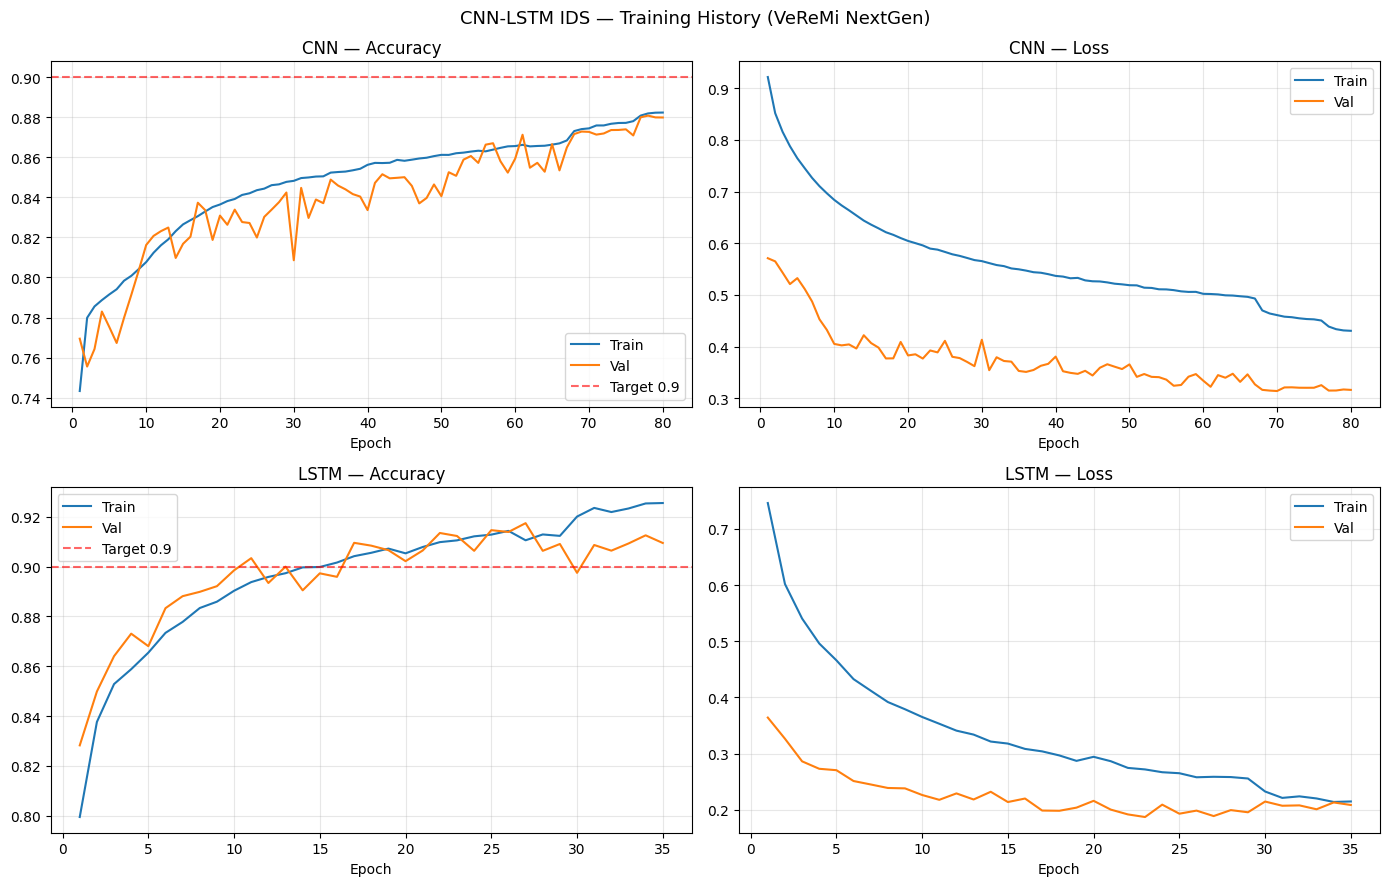

Saved: training_curves.png


In [13]:
# Cell 12 — Training Curves
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('CNN-LSTM IDS — Training History (VeReMi NextGen)', fontsize=13)

for row, (name, h) in enumerate([('CNN', h_cnn), ('LSTM', h_lstm)]):
    ep = range(1, len(h.history['loss']) + 1)

    axes[row][0].plot(ep, h.history['accuracy'],     label='Train')
    axes[row][0].plot(ep, h.history['val_accuracy'], label='Val')
    axes[row][0].axhline(TARGET_F1, color='r', ls='--', label=f'Target {TARGET_F1}', alpha=0.6)
    axes[row][0].set_title(f'{name} — Accuracy')
    axes[row][0].set_xlabel('Epoch')
    axes[row][0].legend()
    axes[row][0].grid(True, alpha=0.3)

    axes[row][1].plot(ep, h.history['loss'],     label='Train')
    axes[row][1].plot(ep, h.history['val_loss'], label='Val')
    axes[row][1].set_title(f'{name} — Loss')
    axes[row][1].set_xlabel('Epoch')
    axes[row][1].legend()
    axes[row][1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')


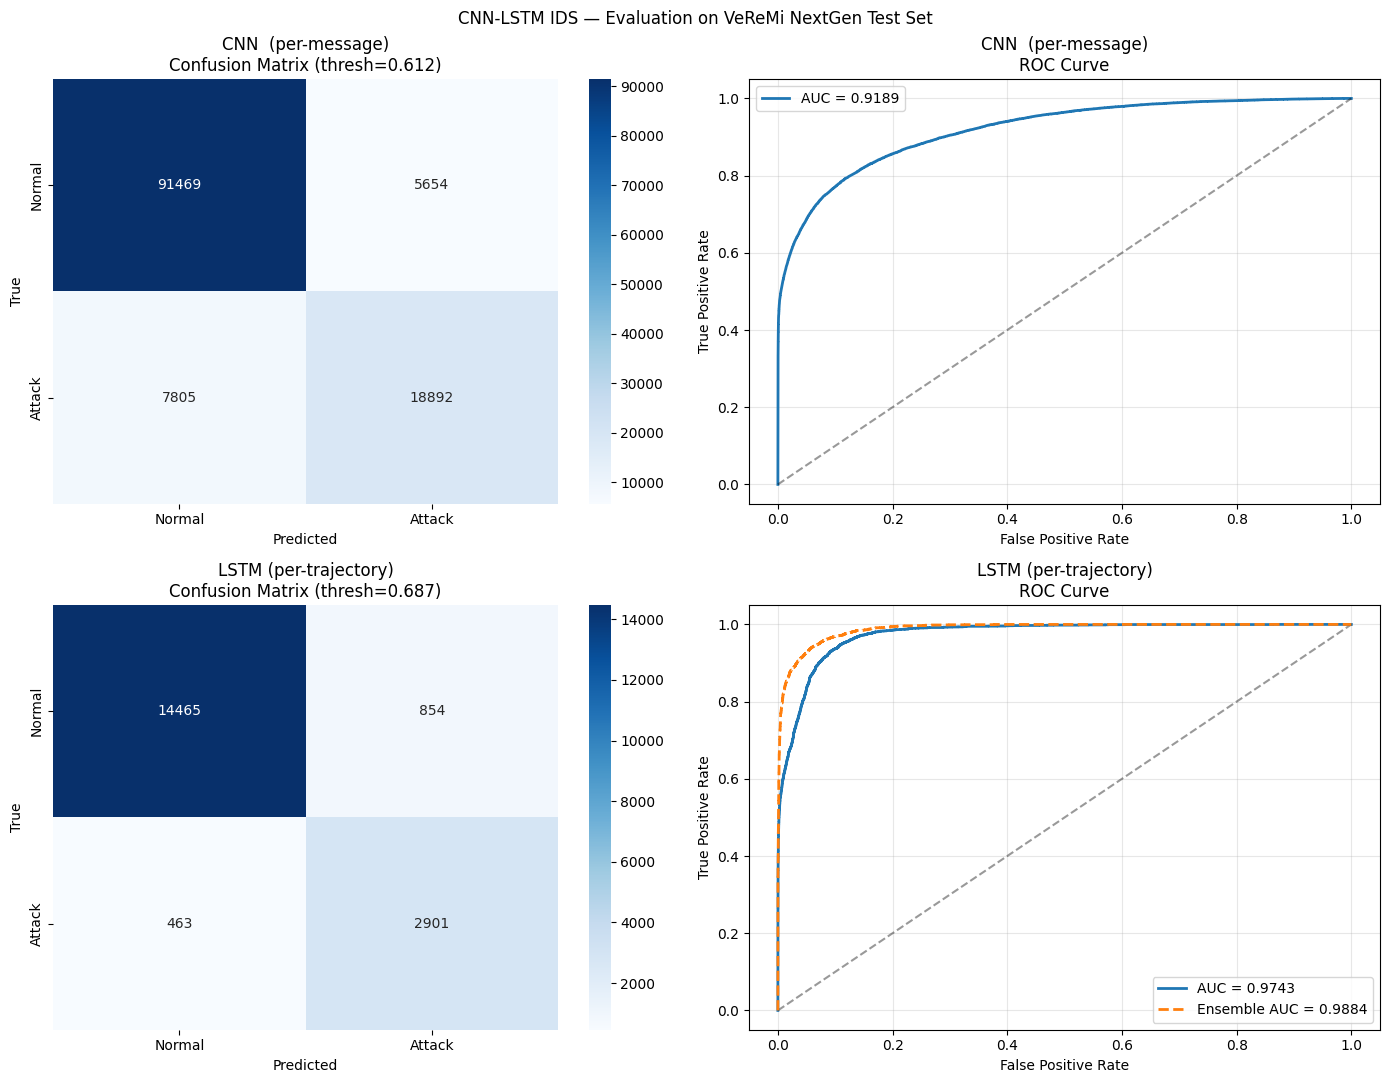

Saved: evaluation_plots.png


In [14]:
# Cell 13 — Confusion Matrices + ROC Curves
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('CNN-LSTM IDS — Evaluation on VeReMi NextGen Test Set', fontsize=12)

eval_pairs = [
    ('CNN  (per-message)',    y_te,     scores_cnn,  res_cnn['threshold']),
    ('LSTM (per-trajectory)', y_seq_te, scores_lstm, res_lstm['threshold']),
]

for row, (name, y_true, scores, thresh) in enumerate(eval_pairs):
    yp = (scores >= thresh).astype(int)

    # Confusion matrix
    cm = confusion_matrix(y_true, yp)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[row][0], cmap='Blues',
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'])
    axes[row][0].set_title(f'{name}\nConfusion Matrix (thresh={thresh:.3f})')
    axes[row][0].set_ylabel('True')
    axes[row][0].set_xlabel('Predicted')

    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, scores)
    auc_val = roc_auc_score(y_true, scores)
    axes[row][1].plot(fpr, tpr, lw=2, label=f'AUC = {auc_val:.4f}')
    axes[row][1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
    axes[row][1].set_xlabel('False Positive Rate')
    axes[row][1].set_ylabel('True Positive Rate')
    axes[row][1].set_title(f'{name}\nROC Curve')
    axes[row][1].legend()
    axes[row][1].grid(True, alpha=0.3)

# Also add ensemble ROC
fpr_e, tpr_e, _ = roc_curve(y_seq_te, scores_ensemble)
auc_e = roc_auc_score(y_seq_te, scores_ensemble)
axes[1][1].plot(fpr_e, tpr_e, lw=2, ls='--', label=f'Ensemble AUC = {auc_e:.4f}')
axes[1][1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: evaluation_plots.png')


In [15]:
# Cell 14 — Per-Attack-Type Breakdown (Ensemble on LSTM test sequences)
print('=== PER-ATTACK-TYPE BREAKDOWN ===')
print('Model: Ensemble (CNN + LSTM) on VeReMi NextGen test set')
print()

thresh_ens = res_ensemble['threshold']
pred_ens   = (scores_ensemble >= thresh_ens).astype(int)

print(f'  {"Attack type":<37} {"F1":>7} {"Recall":>8} {"Prec":>7} {"N":>7}')
print('-' * 70)

results_per_type = {}
for atype in sorted(set(at_seq_te)):
    mask = at_seq_te == atype
    n    = mask.sum()
    if n < 5:
        continue
    f1  = f1_score(y_seq_te[mask], pred_ens[mask], zero_division=0)
    rec = recall_score(y_seq_te[mask], pred_ens[mask], zero_division=0)
    pre = precision_score(y_seq_te[mask], pred_ens[mask], zero_division=0)
    results_per_type[atype] = dict(f1=f1, recall=rec, precision=pre, n=int(n))
    flag = '' if f1 >= 0.80 else '  <-- low'
    print(f'  {atype:<37} {f1:>7.4f} {rec:>8.4f} {pre:>7.4f} {n:>7,}{flag}')


=== PER-ATTACK-TYPE BREAKDOWN ===
Model: Ensemble (CNN + LSTM) on VeReMi NextGen test set

  Attack type                                F1   Recall    Prec       N
----------------------------------------------------------------------
  accelerationMultiplication             0.8949   0.8098  1.0000   1,187
  constantPositionOffset                 0.9961   0.9922  1.0000   1,205
  dataReplay                             0.9783   0.9713  0.9854   1,237
  dosAttack                              0.9617   0.9262  1.0000   1,880
  feignedBraking                         0.8543   0.7798  0.9444   1,198
  normal                                 0.0000   0.0000  0.0000   1,190  <-- low
  positionMirroring                      0.9425   0.9572  0.9283   1,202
  randomPositionOffset                   0.9425   1.0000  0.8913   1,207
  randomSpeedOffset                      0.7841   0.8150  0.7555   1,203  <-- low
  reversedHeading                        0.8900   0.8532  0.9300   1,200
  suddenConstantS

=== NOISE ROBUSTNESS TEST ===
Gaussian noise added to normalised CNN test features

  Noise std      CNN F1   LSTM F1  Ensemble F1
----------------------------------------------
  sigma=0.00        0.7373    0.8150       0.8885
  sigma=0.05        0.5583    0.8114       0.8629
  sigma=0.10        0.4421    0.7956       0.8011
  sigma=0.20        0.3811    0.7193       0.6774
  sigma=0.30        0.3660    0.6256       0.5757
  sigma=0.50        0.3564    0.4970       0.4688


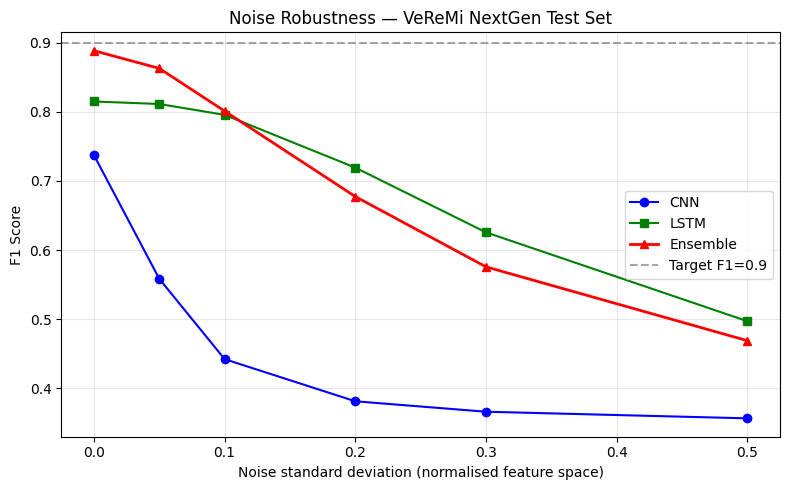

Saved: noise_robustness.png


In [16]:
# Cell 15 — Noise Robustness Test
# Adds Gaussian noise to the test set features and measures how metrics degrade.
# A robust model maintains performance at low noise levels (std <= 0.20).
print('=== NOISE ROBUSTNESS TEST ===')
print('Gaussian noise added to normalised CNN test features')
print()

noise_levels = [0.0, 0.05, 0.10, 0.20, 0.30, 0.50]
cnn_f1s, lstm_f1s, ens_f1s = [], [], []

thresh_cnn  = res_cnn['threshold']
thresh_lstm = res_lstm['threshold']
thresh_ens  = res_ensemble['threshold']

print(f'  {"Noise std":<12} {"CNN F1":>8} {"LSTM F1":>9} {"Ensemble F1":>12}')
print('-' * 46)

for sigma in noise_levels:
    # CNN on noisy individual messages
    Xn = X_te + np.random.normal(0, sigma, X_te.shape).astype(np.float32)
    sc = predict_proba(cnn, Xn)
    f1_cnn = f1_score(y_te, (sc >= thresh_cnn).astype(int), zero_division=0)

    # LSTM on noisy sequences
    Xsn = X_seq_te + np.random.normal(0, sigma, X_seq_te.shape).astype(np.float32)
    sl  = predict_proba(lstm, Xsn)
    f1_lstm = f1_score(y_seq_te, (sl >= thresh_lstm).astype(int), zero_division=0)

    # Ensemble on noisy sequences
    flat_n  = Xsn.reshape(-1, FEAT_DIM)
    sc_flat = predict_proba(cnn, flat_n).reshape(-1, WINDOW_SIZE).mean(axis=1)
    se      = (sc_flat + sl) / 2.0
    f1_ens  = f1_score(y_seq_te, (se >= thresh_ens).astype(int), zero_division=0)

    cnn_f1s.append(f1_cnn)
    lstm_f1s.append(f1_lstm)
    ens_f1s.append(f1_ens)
    print(f'  sigma={sigma:<6.2f}    {f1_cnn:>8.4f} {f1_lstm:>9.4f} {f1_ens:>12.4f}')

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(noise_levels, cnn_f1s,  'b-o', label='CNN')
ax.plot(noise_levels, lstm_f1s, 'g-s', label='LSTM')
ax.plot(noise_levels, ens_f1s,  'r-^', label='Ensemble', lw=2)
ax.axhline(TARGET_F1, color='gray', ls='--', label=f'Target F1={TARGET_F1}', alpha=0.7)
ax.set_xlabel('Noise standard deviation (normalised feature space)')
ax.set_ylabel('F1 Score')
ax.set_title('Noise Robustness — VeReMi NextGen Test Set')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/noise_robustness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: noise_robustness.png')


## Save Models & Download


In [17]:
# Cell 16 — Save Models + Results to Google Drive
cnn.save(f'{OUTPUT_DIR}/cnn_model.keras')
lstm.save(f'{OUTPUT_DIR}/lstm_model.keras')
joblib.dump(scaler, f'{OUTPUT_DIR}/feature_scaler.pkl')

metadata = {
    'dataset':       'VeReMi NextGen (Ulm University, CC-BY 4.0)',
    'architecture':  'CNN-LSTM Hybrid Ensemble',
    'features':      FEATURE_COLS,
    'window_size':   WINDOW_SIZE,
    'cnn_threshold':  res_cnn['threshold'],
    'lstm_threshold': res_lstm['threshold'],
    'ensemble_threshold': res_ensemble['threshold'],
    'results': {
        'cnn':      res_cnn,
        'lstm':     res_lstm,
        'ensemble': res_ensemble,
        'per_attack_type': results_per_type,
    },
}
with open(f'{OUTPUT_DIR}/evaluation_results.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'Saved to {OUTPUT_DIR}:')
print('  cnn_model.keras')
print('  lstm_model.keras')
print('  feature_scaler.pkl')
print('  evaluation_results.json')
print()
print('=' * 68)
print('  FINAL RESULTS')
print('=' * 68)
print(f'  {"Model":<32} {"F1":>7} {"AUC":>7} {"Recall":>8}   Status')
print('-' * 68)
for r in [res_cnn, res_lstm, res_ensemble]:
    ok = ('PASS' if r['f1_score'] >= TARGET_F1
                 and r['roc_auc'] >= TARGET_AUC
                 and r['recall']  >= TARGET_RECALL else 'FAIL')
    print(f'  {r["name"]:<32} {r["f1_score"]:>7.4f} {r["roc_auc"]:>7.4f} '
          f'{r["recall"]:>8.4f}   {ok}')
print('=' * 68)


Saved to /content/drive/MyDrive/V2X_IDS_Models:
  cnn_model.keras
  lstm_model.keras
  feature_scaler.pkl
  evaluation_results.json

  FINAL RESULTS
  Model                                 F1     AUC   Recall   Status
--------------------------------------------------------------------
  CNN  (per-message)                0.7373  0.9189   0.7076   FAIL
  LSTM (per-trajectory)             0.8150  0.9743   0.8624   FAIL
  Ensemble  CNN + LSTM              0.8885  0.9884   0.8787   FAIL


In [18]:
# Cell 17 — Package All Outputs as Zip for Download
import zipfile

zip_path = '/content/v2x_ids_models.zip'
files = [
    'cnn_model.keras', 'lstm_model.keras',
    'feature_scaler.pkl', 'evaluation_results.json',
    'training_curves.png', 'evaluation_plots.png', 'noise_robustness.png',
]
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in files:
        fp = f'{OUTPUT_DIR}/{fname}'
        if os.path.exists(fp):
            zf.write(fp, fname)
            print(f'  + {fname}')
        else:
            print(f'  - {fname}  (not found — skipping)')

size_mb = os.path.getsize(zip_path) / 1e6
print(f'\nZip: {zip_path}  ({size_mb:.1f} MB)')
print()
print('Download options:')
print('  VS Code: Explorer panel → right-click v2x_ids_models.zip → Download')
print('  Colab:   Files panel (folder icon) → right-click → Download')
print('  Or:      Files are already saved to Google Drive at', OUTPUT_DIR)


  + cnn_model.keras
  + lstm_model.keras
  + feature_scaler.pkl
  + evaluation_results.json
  + training_curves.png
  + evaluation_plots.png
  + noise_robustness.png

Zip: /content/v2x_ids_models.zip  (1.3 MB)

Download options:
  VS Code: Explorer panel → right-click v2x_ids_models.zip → Download
  Colab:   Files panel (folder icon) → right-click → Download
  Or:      Files are already saved to Google Drive at /content/drive/MyDrive/V2X_IDS_Models
